# TASK 3 — Country-Wise Netflix Content Analysis

Task Requirements

Extract and clean country information , 
Calculate content count by country , 
Identify top content-producing countries , 
Create charts and rankings , 
Generate business insights.

In [1]:
%pip install seaborn
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# loading the cleaned dataset

df = pd.read_csv("Netflix_Cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head(5)

Dataset loaded successfully!
Shape: (8790, 14)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_month_name,duration_value
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,September,90.0
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,September,1.0
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,September,1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,September,91.0
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,September,125.0


In [4]:
# checking country information

print("Country column:")
print(df["country"].head(10))

Country column:
0     United States
1            France
2     United States
3            Brazil
4     United States
5    United Kingdom
6     United States
7             India
8           Germany
9             India
Name: country, dtype: str


In [5]:
# checking missing values in country column

print("Missing country values:")
print(df["country"].isnull().sum())

Missing country values:
0


In [6]:
# removing extra spaces from country names

df["country"] = df["country"].astype(str).str.strip()

# splitting multiple countries

country_df = df.copy()

country_df["country"] = country_df["country"].str.split(",")

# creating separate row for each country

country_df = country_df.explode("country")

# removing extra spaces

country_df["country"] = country_df["country"].str.strip()

print("Country data cleaned successfully!")

country_df[["title", "country"]].head(10)

Country data cleaned successfully!


,title,country
0,Dick Johnson Is Dead,United States
1,Ganglands,France
2,Midnight Mass,United States
3,Confessions of an Invisible Girl,Brazil
4,Sankofa,United States
5,The Great British Baking Show,United Kingdom
6,The Starling,United States
7,Motu Patlu in the Game of Zones,India
8,Je Suis Karl,Germany
9,Motu Patlu in Wonderland,India


In [7]:
# calculating number of Netflix titles by country

country_counts = country_df["country"].value_counts()

print("Top 20 countries by number of Netflix titles:")
print(country_counts.head(20))

Top 20 countries by number of Netflix titles:
country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Egypt              123
Australia          114
Turkey             112
Nigeria            105
Germany            104
China              100
Brazil              88
Taiwan              86
Indonesia           86
Name: count, dtype: int64


In [8]:
# creating country ranking table

country_ranking = country_counts.reset_index()

country_ranking.columns = [
    "Country",
    "Content_Count"
]

country_ranking["Rank"] = (
    country_ranking["Content_Count"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

country_ranking = country_ranking[
    ["Rank", "Country", "Content_Count"]
]

country_ranking.head(20)

,Rank,Country,Content_Count
0,1,United States,3240
1,2,India,1057
2,3,United Kingdom,638
3,4,Pakistan,421
4,5,Not Given,287
5,6,Canada,271
6,7,Japan,259
7,8,South Korea,214
8,9,France,213
9,10,Spain,182


In [9]:
# selecting top 10 content-producing countries

top_10_countries = country_counts.head(10)

print("Top 10 Content-Producing Countries:")
print(top_10_countries)

Top 10 Content-Producing Countries:
country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64


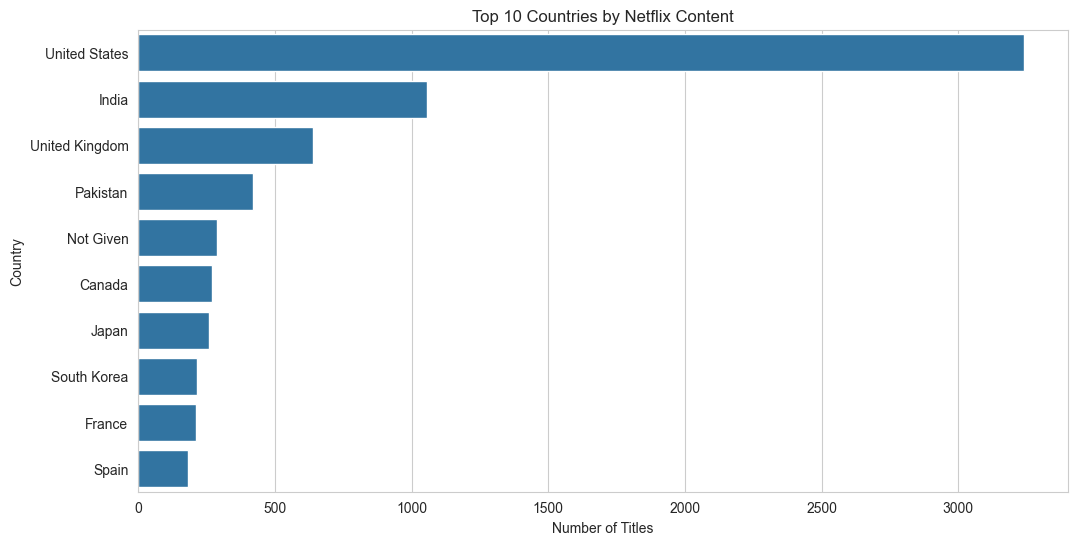

In [10]:
# visualizing top 10 countries

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_countries.values,
    y=top_10_countries.index
)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

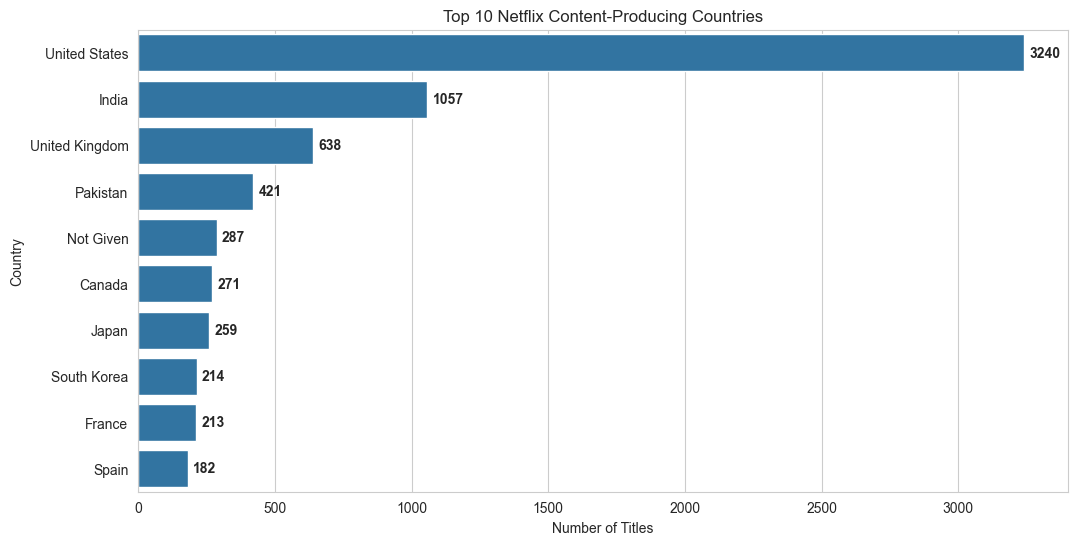

In [11]:
# creating bar chart with values

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_10_countries.values,
    y=top_10_countries.index
)

plt.title("Top 10 Netflix Content-Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

for i, value in enumerate(top_10_countries.values):
    ax.text(
        value + 20,
        i,
        str(value),
        va="center",
        fontweight="bold"
    )

plt.show()

In [12]:
# analyzing movies and TV shows by country

country_type = (
    country_df
    .groupby(["country", "type"])
    .size()
    .unstack(fill_value=0)
)

country_type.head(10)

type,Movie,Tv Show
country,,
Argentina,56,20
Australia,61,53
Austria,8,1
Bangladesh,3,0
Belarus,0,1
Belgium,9,9
Brazil,60,28
Bulgaria,5,0
Cambodia,2,0


In [13]:
# selecting top 10 countries

top_country_names = country_counts.head(10).index

top_country_type = country_type.loc[
    country_type.index.intersection(top_country_names)
]

top_country_type

type,Movie,Tv Show
country,,
Canada,187,84
France,148,65
India,976,81
Japan,87,172
Not Given,257,30
Pakistan,71,350
South Korea,49,165
Spain,129,53
United Kingdom,387,251


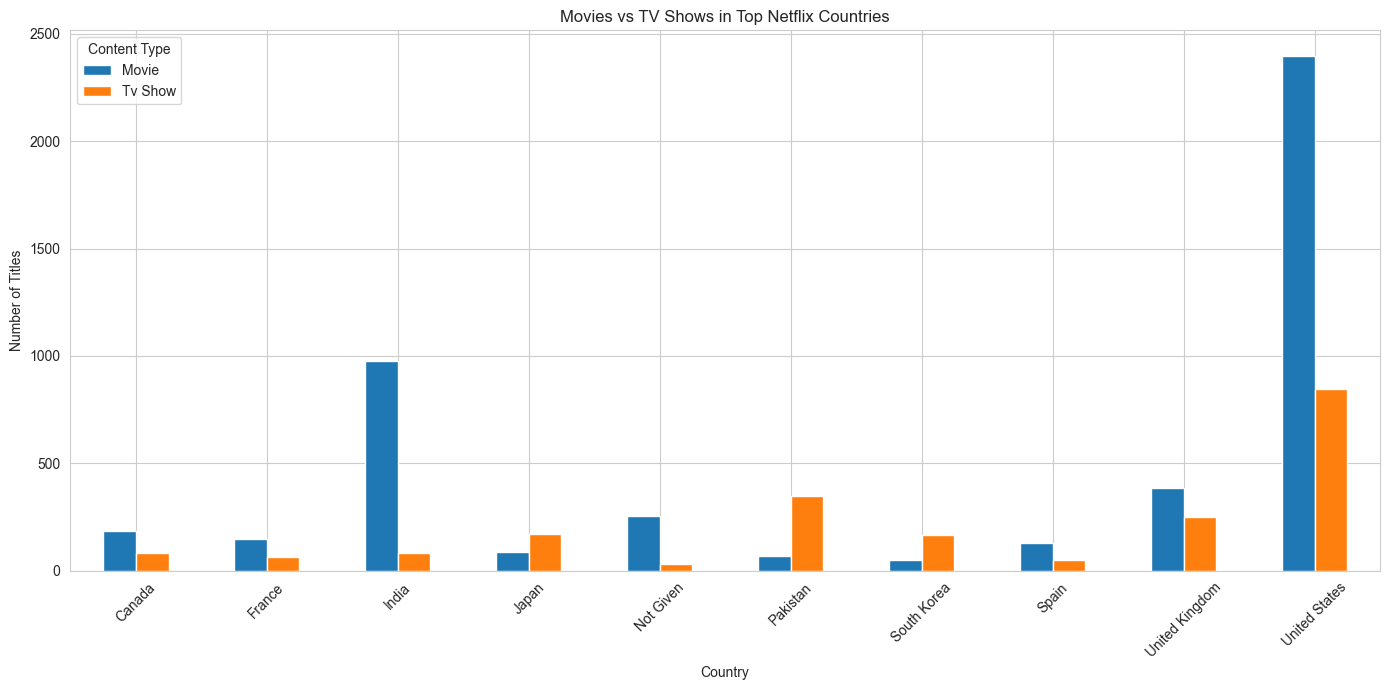

In [14]:
# visualizing content type by country

top_country_type.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Movies vs TV Shows in Top Netflix Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.legend(title="Content Type")

plt.tight_layout()

plt.show()

In [15]:
# identifying the country with the highest content count

top_country = country_counts.index[0]
top_country_count = country_counts.iloc[0]

print("Top Content-Producing Country:", top_country)
print("Number of Titles:", top_country_count)

Top Content-Producing Country: United States
Number of Titles: 3240


In [16]:
# displaying top 5 countries

for i, (country, count) in enumerate(
    country_counts.head(5).items(),
    start=1
):
    print(f"{i}. {country} - {count} titles")

1. United States - 3240 titles
2. India - 1057 titles
3. United Kingdom - 638 titles
4. Pakistan - 421 titles
5. Not Given - 287 titles


In [17]:
# generating business insights

print("=" * 55)
print("          BUSINESS INSIGHTS")
print("=" * 55)

print(
    f"\n1. The country with the highest number of "
    f"Netflix titles is {top_country}."
)

print(
    f"2. It has approximately {top_country_count} "
    f"titles in the dataset."
)

print("\n3. Top 5 content-producing countries:")

for i, (country, count) in enumerate(
    country_counts.head(5).items(),
    start=1
):
    print(f"   {i}. {country}: {count} titles")

print(
    "\n4. Country-wise analysis helps identify "
    "major Netflix content-producing markets."
)

print(
    "5. This information can help businesses understand "
    "geographic content distribution and market focus."
)

          BUSINESS INSIGHTS

1. The country with the highest number of Netflix titles is United States.
2. It has approximately 3240 titles in the dataset.

3. Top 5 content-producing countries:
   1. United States: 3240 titles
   2. India: 1057 titles
   3. United Kingdom: 638 titles
   4. Pakistan: 421 titles
   5. Not Given: 287 titles

4. Country-wise analysis helps identify major Netflix content-producing markets.
5. This information can help businesses understand geographic content distribution and market focus.


In [18]:
# displaying top 20 country ranking

country_ranking.head(20)

,Rank,Country,Content_Count
0,1,United States,3240
1,2,India,1057
2,3,United Kingdom,638
3,4,Pakistan,421
4,5,Not Given,287
5,6,Canada,271
6,7,Japan,259
7,8,South Korea,214
8,9,France,213
9,10,Spain,182


In [19]:
# exporting country analysis

country_ranking.to_csv(
    "Netflix_Country_Analysis.csv",
    index=False
)

print("Country analysis exported successfully!")
print("File: Netflix_Country_Analysis.csv")

Country analysis exported successfully!
File: Netflix_Country_Analysis.csv
